# 01 — What arrives at the antenna

**Goal of this notebook:** understand the signal *before* any CAM is involved, so that
every later design decision has a reason you can point at.

By the end you should be able to answer:

1. Why can 32 satellites share one frequency? (the C/A code)
2. What exactly is `r[n]`, and what is unknown about it?
3. Why is the GPS signal *invisible* in the time domain, and where does the gain come from?
4. Why is "how many milliseconds to acquire" the question this whole repo answers?
5. Why does the search need ~1.3 million cells?

Modules used: [`sim/gps/prn.py`](../sim/gps/prn.py), [`sim/gps/channel.py`](../sim/gps/channel.py).

In [1]:
import sys, pathlib
ROOT = pathlib.Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np
import matplotlib.pyplot as plt

from sim.gps import prn, channel, codebook, baselines

plt.rcParams.update({"figure.figsize": (9, 3), "figure.dpi": 110, "axes.grid": True,
                     "grid.alpha": 0.3, "font.size": 9})

# The operating point used throughout the repo.
FS   = 2.046e6      # sampling rate, Hz  -> OSR = 2 samples per chip
T    = 1e-3         # one C/A code period = one "dwell"
NS   = int(round(FS * T))
print(f"{NS} samples per 1 ms dwell, OSR = {FS / prn.CHIP_RATE:.0f} samples/chip")

2046 samples per 1 ms dwell, OSR = 2 samples/chip


---
## 1. The C/A code — why 32 satellites can share one frequency

Every GPS satellite transmits on the *same* carrier (L1 = 1575.42 MHz). They are separated
not in frequency but by **code**: each PRN is assigned a distinct 1023-chip Gold code,
repeating every 1 ms, that multiplies the data.

`prn.ca_code(k)` runs the two 10-stage LFSRs from IS-GPS-200. The only thing that makes
this work is a *correlation* property, which we check rather than assume.

In [2]:
code = prn.ca_code(1)
print("PRN 1, first 10 chips:", code[:10])

# IS-GPS-200 publishes the first 10 chips as an octal word. This is the ground truth.
got = int("".join(map(str, code[:10])), 2)
print(f"as octal: {got:o}   spec says: {prn.FIRST10_OCTAL[1]:o}   match: {got == prn.FIRST10_OCTAL[1]}")

ones = int(code.sum())
print(f"length {len(code)}, ones {ones}, zeros {len(code) - ones}  (a C/A code is 'balanced')")

PRN 1, first 10 chips: [1 1 0 0 1 0 0 0 0 0]
as octal: 1440   spec says: 1440   match: True
length 1023, ones 512, zeros 511  (a C/A code is 'balanced')


### Autocorrelation: the code only looks like itself when perfectly aligned

Shift the code against itself by any non-zero number of chips and the correlation collapses
from 1023 to one of just three small values. This is the *entire* basis of code-phase
acquisition: a sharp peak exactly one chip wide.

distinct off-peak values: [-65, -1, 63]  <- three-valued, as theory says
peak 1023  vs  worst off-peak 65   (23.9 dB of separation)


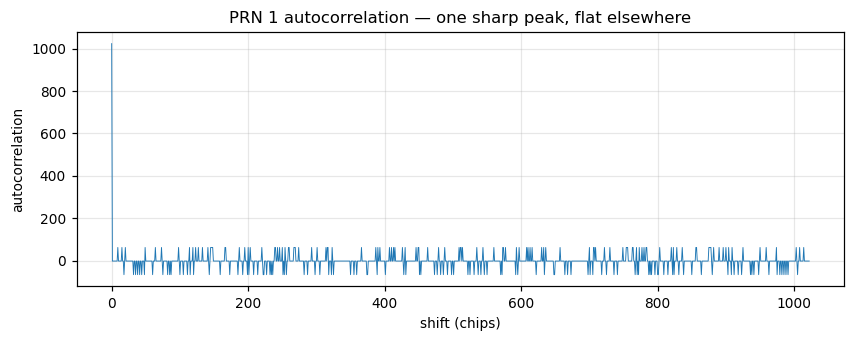

In [3]:
c1 = prn.ca_code_bipolar(1)            # +-1 version
ac = np.array([c1 @ np.roll(c1, k) for k in range(prn.CODE_LENGTH)])

print("distinct off-peak values:", sorted(set(ac[1:].astype(int))), " <- three-valued, as theory says")
print(f"peak {ac[0]:.0f}  vs  worst off-peak {np.abs(ac[1:]).max():.0f}"
      f"   ({20 * np.log10(ac[0] / np.abs(ac[1:]).max()):.1f} dB of separation)")

fig, ax = plt.subplots()
ax.plot(ac, lw=0.6)
ax.set(xlabel="shift (chips)", ylabel="autocorrelation", title="PRN 1 autocorrelation — one sharp peak, flat elsewhere")
plt.show()

### Cross-correlation: a *different* satellite looks like noise

Same bound (65 out of 1023) applies between two different PRNs. So a receiver looking for
PRN 1 sees PRN 7 as a ~24 dB weaker interferer, not as a competing peak. That is CDMA.

In [4]:
c2 = prn.ca_code_bipolar(2)
xc = np.array([c1 @ np.roll(c2, k) for k in range(prn.CODE_LENGTH)])
print(f"max |cross-correlation| PRN1 vs PRN2: {np.abs(xc).max():.0f}   (vs autocorrelation peak 1023)")
print("distinct values:", sorted(set(xc.astype(int))))

max |cross-correlation| PRN1 vs PRN2: 65   (vs autocorrelation peak 1023)
distinct values: [-65, -1, 63]


> **Why this matters downstream.** The CAM stores one row per (PRN, Doppler). The reason a
> wrong-PRN row does not fire is exactly this bound. In notebook 03 we will measure the
> Hamming distance to a wrong-PRN row and find it sits right at "chance" — which is the
> bit-domain restatement of what we just plotted.

---
## 2. Sampling: chips → samples

The code is a sequence of *chips*; the receiver works with *samples*. This repo samples at
`FS = 2.046 MHz`, exactly 2 samples per chip (OSR = 2), giving 2046 samples per 1 ms period.

`prn.upsample` does zero-order-hold sampling starting at a possibly *fractional* code phase,
wrapping cyclically. That fractional start is the unknown a receiver must find.

In [5]:
short = prn.ca_code_bipolar(1)[:6]
print("first 6 chips          :", short)
print("upsampled at OSR=2     :", prn.upsample(prn.ca_code_bipolar(1), osr=2, n_samples=12))
print("...but starting at chip phase 2.5 (half-chip offset):")
print("                        ", prn.upsample(prn.ca_code_bipolar(1), osr=2, code_phase_chips=2.5, n_samples=12))

first 6 chips          : [-1. -1.  1.  1. -1.  1.]
upsampled at OSR=2     : [-1. -1. -1. -1.  1.  1.  1.  1. -1. -1.  1.  1.]
...but starting at chip phase 2.5 (half-chip offset):
                         [ 1.  1.  1. -1. -1.  1.  1.  1.  1.  1.  1.  1.]


---
## 3. The received signal

[`channel.generate`](../sim/gps/channel.py) builds one realization of

$$ r[n] \;=\; A \cdot c[n-\tau] \cdot d \cdot e^{\,j(2\pi f_d n T_s + \theta_0)} \;+\; w[n] $$

| symbol | meaning | known? |
|---|---|---|
| $c$ | the PRN's code | **unknown** — which satellite is up there? (32 options) |
| $\tau$ | code phase | **unknown** — 1023 chip-spaced options |
| $f_d$ | Doppler shift | **unknown** — $\pm$10 kHz cold start |
| $\theta_0$ | carrier phase at $n=0$ | **unknown** — uniform on $[0, 2\pi)$ |
| $A$ | amplitude | set by C/N0 |
| $w$ | complex Gaussian noise | $\sigma = 1$ per rail |

Four unknowns. Acquisition = search over the first three; $\theta_0$ turns out to be
*free* to sweep, which is the architectural trick of this project (notebook 02).

returned object: Signal -> ['samples', 'prn', 'fd', 'theta0', 'code_phase_chips']
truth stored alongside the samples: prn=1, fd=0.0, theta0=0.0, code_phase=0.0


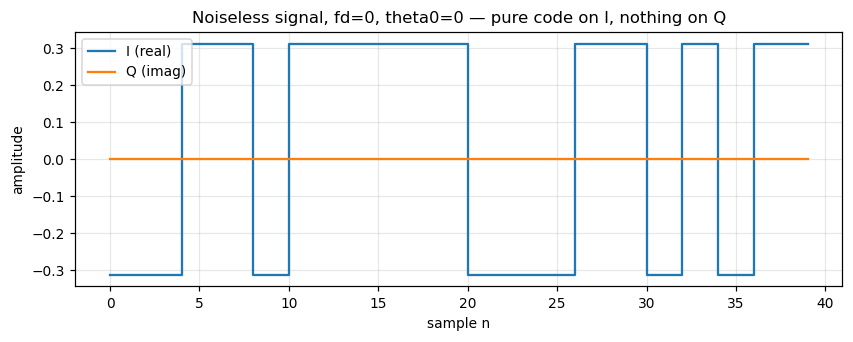

In [6]:
sig = channel.generate(prn=1, cn0_dbhz=50, fd=0.0, fs=FS, n_samples=NS,
                       theta0=0.0, code_phase_chips=0.0, noise=False)
print("returned object:", type(sig).__name__, "->", [f for f in sig.__dataclass_fields__])
print("truth stored alongside the samples:",
      f"prn={sig.prn}, fd={sig.fd}, theta0={sig.theta0}, code_phase={sig.code_phase_chips}")

fig, ax = plt.subplots()
ax.step(np.arange(40), sig.samples.real[:40], where="post", label="I (real)")
ax.step(np.arange(40), sig.samples.imag[:40], where="post", label="Q (imag)")
ax.set(xlabel="sample n", ylabel="amplitude", title="Noiseless signal, fd=0, theta0=0 — pure code on I, nothing on Q")
ax.legend()
plt.show()

**Notice the Q rail is dead.** At $\theta_0 = 0$ and $f_d = 0$ the signal is purely real.
Remember this picture — in notebook 03 it reappears as a *bug* that the sanity gates caught:
codebook rows built at $\theta = 0$ waste half the CAM match line on a constant.

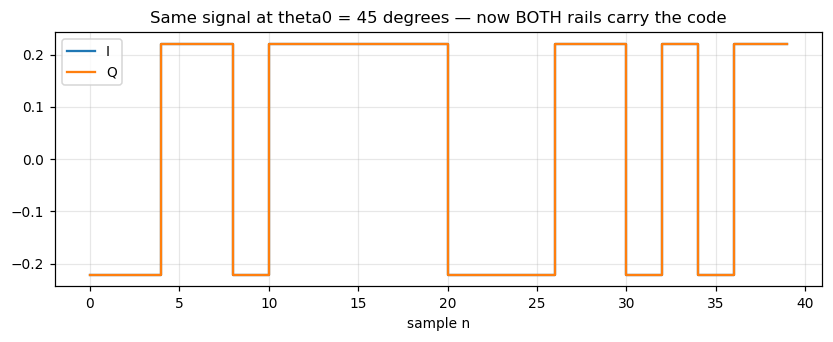

In [7]:
sig_rot = channel.generate(1, 50, fd=0.0, fs=FS, n_samples=NS,
                           theta0=np.pi / 4, code_phase_chips=0.0, noise=False)
fig, ax = plt.subplots()
ax.step(np.arange(40), sig_rot.samples.real[:40], where="post", label="I")
ax.step(np.arange(40), sig_rot.samples.imag[:40], where="post", label="Q")
ax.set(title="Same signal at theta0 = 45 degrees — now BOTH rails carry the code", xlabel="sample n")
ax.legend()
plt.show()

---
## 4. C/N0, and the "settled AGC" convention

Signal strength is quoted as **C/N0** in dB-Hz: carrier power over noise power *spectral
density*. It is a property of the link, independent of your receiver's bandwidth — which is
why GNSS uses it instead of SNR.

The repo makes a deliberate choice ([`channel.py`](../sim/gps/channel.py)): **fix the noise at
$\sigma = 1$ and scale the signal**, rather than fixing the signal and scaling noise. Both
are valid, but only this one keeps the ADC thresholds fixed across a C/N0 sweep — which is
what a real front end with a settled AGC does. If we scaled the noise instead, the 2-bit
quantizer in notebook 02 would silently change its operating point at every C/N0.

In [8]:
for cn0 in [38, 42, 45, 50]:
    A = channel.amplitude_for_cn0(cn0, FS)
    snr = A ** 2 / (2 * channel.SIGMA ** 2)          # |s|^2 over noise power in both rails
    print(f"C/N0 = {cn0} dB-Hz -> A = {A:.4f}, per-sample SNR = {10 * np.log10(snr):6.2f} dB")

print("\n38 dB-Hz is the repo's weak-signal operating point: the signal sits 25 dB BELOW the noise.")

C/N0 = 38 dB-Hz -> A = 0.0785, per-sample SNR = -25.11 dB
C/N0 = 42 dB-Hz -> A = 0.1245, per-sample SNR = -21.11 dB
C/N0 = 45 dB-Hz -> A = 0.1758, per-sample SNR = -18.11 dB
C/N0 = 50 dB-Hz -> A = 0.3127, per-sample SNR = -13.11 dB

38 dB-Hz is the repo's weak-signal operating point: the signal sits 25 dB BELOW the noise.


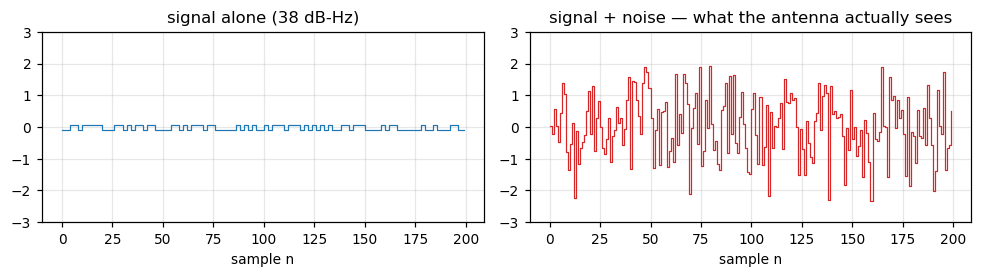

signal peak-to-peak 0.157  vs  noise std 1.005
The signal is not 'hard to see'. It is invisible. Nothing in the time domain will help.


In [9]:
rng = np.random.default_rng(0)
clean = channel.generate(1, 38, 0.0, FS, NS, theta0=0.0, code_phase_chips=0.0,
                         rng=rng, noise=False).samples
rng = np.random.default_rng(0)
noisy = channel.generate(1, 38, 0.0, FS, NS, theta0=0.0, code_phase_chips=0.0, rng=rng).samples

fig, axes = plt.subplots(1, 2, figsize=(9, 2.6))
axes[0].step(np.arange(200), clean.real[:200], where="post", lw=0.8)
axes[0].set(title="signal alone (38 dB-Hz)", xlabel="sample n", ylim=(-3, 3))
axes[1].step(np.arange(200), noisy.real[:200], where="post", lw=0.8, color="C3")
axes[1].set(title="signal + noise — what the antenna actually sees", xlabel="sample n", ylim=(-3, 3))
plt.tight_layout(); plt.show()

print(f"signal peak-to-peak {clean.real.ptp():.3f}  vs  noise std {noisy.real.std():.3f}")
print("The signal is not 'hard to see'. It is invisible. Nothing in the time domain will help.")

---
## 5. Where the processing gain comes from

Correlating over the full 1 ms period coherently adds 2046 samples of signal (which add in
*amplitude*, $\propto N$) against noise (which adds in *power*, $\propto \sqrt N$). The gain is

$$ 10\log_{10}(N) = 10\log_{10}(2046) = 33.1\ \text{dB} $$

So $-25.1$ dB per sample becomes $+8$ dB after 1 ms. That single number is the budget the
entire rest of this repo spends.

In [10]:
N_gain = 10 * np.log10(NS)
snr_sample = 10 * np.log10(channel.amplitude_for_cn0(38, FS) ** 2 / 2)
print(f"per-sample SNR    {snr_sample:6.2f} dB")
print(f"coherent gain     {N_gain:+6.2f} dB   (1 ms = {NS} samples)")
print(f"post-correlation  {snr_sample + N_gain:6.2f} dB")
print()
print("Shortcut worth remembering:  post-correlation SNR (dB) = C/N0 - 10*log10(1/T) = C/N0 - 30 for T = 1 ms.")
print(f"check: 38 - 30 = {38 - 30} dB")

per-sample SNR    -25.11 dB
coherent gain     +33.11 dB   (1 ms = 2046 samples)
post-correlation    8.00 dB

Shortcut worth remembering:  post-correlation SNR (dB) = C/N0 - 10*log10(1/T) = C/N0 - 30 for T = 1 ms.
check: 38 - 30 = 8 dB


### Doing the correlation

`baselines.acquire_fft` is the conventional receiver: it wipes the carrier, then gets *all*
2046 code phases at once from an FFT / conjugate-multiply / IFFT. We use it here purely as
a measuring instrument — this is the picture the CAM is trying to reproduce with 1-bit
hardware.

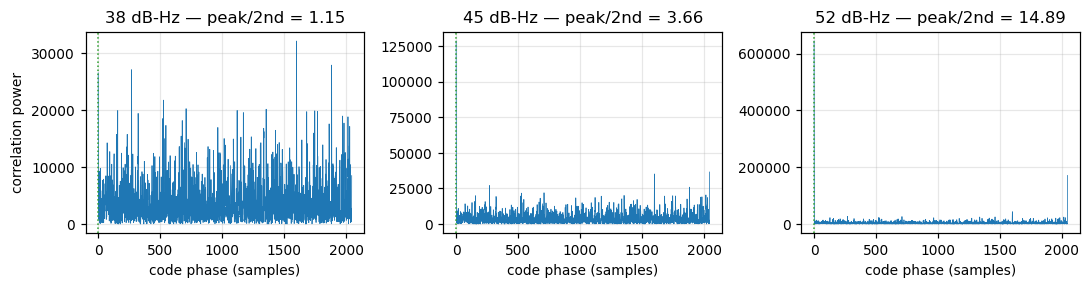

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(10, 2.7), sharex=True)
for ax, cn0 in zip(axes, [38, 45, 52]):
    s = channel.generate(1, cn0, 0.0, FS, NS, theta0=0.0, code_phase_chips=0.0,
                         rng=np.random.default_rng(1))
    res = baselines.acquire_fft(s.samples, 1, np.array([0.0]), FS)
    ax.plot(res.grid[0], lw=0.5)
    ax.set(title=f"{cn0} dB-Hz — peak/2nd = {res.metric:.2f}", xlabel="code phase (samples)")
    ax.axvline(0, color="C2", ls=":", lw=1)
axes[0].set_ylabel("correlation power")
plt.tight_layout(); plt.show()

In [12]:
# Where did the detector actually put the peak? Truth is code phase 0.
for cn0 in [38, 45, 52]:
    s = channel.generate(1, cn0, 0.0, FS, NS, theta0=0.0, code_phase_chips=0.0,
                         rng=np.random.default_rng(1))
    res = baselines.acquire_fft(s.samples, 1, np.array([0.0]), FS)
    verdict = "CORRECT" if min(res.code_phase_samples, NS - res.code_phase_samples) <= 1 else "WRONG"
    print(f"{cn0} dB-Hz: peak at sample {res.code_phase_samples:5d}  (truth 0)  -> {verdict}")

38 dB-Hz: peak at sample  1600  (truth 0)  -> WRONG
45 dB-Hz: peak at sample     0  (truth 0)  -> CORRECT
52 dB-Hz: peak at sample     0  (truth 0)  -> CORRECT


> ### This is the punchline of the notebook
>
> At 38 dB-Hz, **one millisecond is not enough** — the strongest cell is a noise cell, not
> the signal. 8 dB of post-correlation SNR sounds healthy until you remember we must beat
> the *maximum* over ~1.3 million cells, not just the average one.
>
> So the receiver integrates more dwells. And "how many 1 ms dwells do I need?" becomes the
> single figure of merit that every later notebook computes — for the CAM, for the 1-bit
> correlator, and for the full-precision FFT. Acquisition *time* is the currency.

---
## 6. Doppler: why you cannot just correlate and be done

The satellite is moving at ~4 km/s, so the carrier arrives shifted by up to $\pm$5 kHz
(plus receiver oscillator error → the repo budgets $\pm$10 kHz for a cold start).

If your replica's Doppler is wrong by $\Delta f$, the residual carrier *rotates* during the
dwell. Integrate a rotating phasor and it cancels itself. The loss is exactly
$|\mathrm{sinc}(\Delta f \cdot T)|$, hitting a **complete null** at $\Delta f = 1/T$ = 1 kHz.

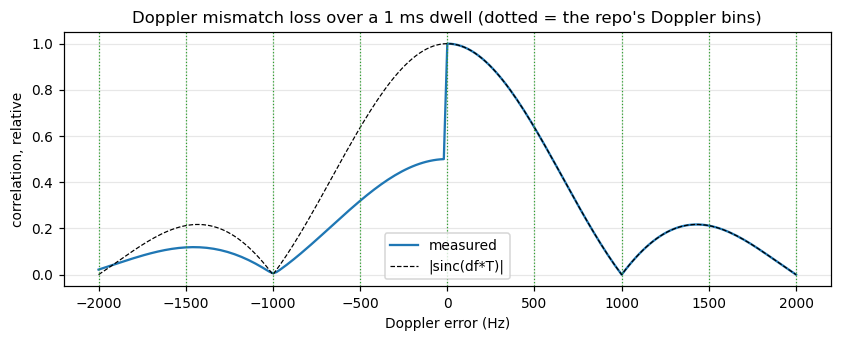

In [13]:
s = channel.generate(1, 50, 0.0, FS, NS, theta0=0.0, code_phase_chips=0.0, noise=False).samples
base = abs(np.vdot(channel.replica(1, 0.0, FS, NS, theta=0.0), s))

fds = np.linspace(-2000, 2000, 201)
loss = [abs(np.vdot(channel.replica(1, f, FS, NS, theta=0.0), s)) / base for f in fds]

fig, ax = plt.subplots()
ax.plot(fds, loss, label="measured")
ax.plot(fds, np.abs(np.sinc(fds * T)), "k--", lw=0.8, label="|sinc(df*T)|")
grid = codebook.doppler_grid(10e3, T)
for g in grid[np.abs(grid) <= 2000]:
    ax.axvline(g, color="C2", ls=":", lw=0.8)
ax.set(xlabel="Doppler error (Hz)", ylabel="correlation, relative",
       title="Doppler mismatch loss over a 1 ms dwell (dotted = the repo's Doppler bins)")
ax.legend(); plt.show()

The dotted lines are the repo's Doppler hypothesis grid. They are spaced $1/(2T) = 500$ Hz,
i.e. **half** the null spacing — so the worst case is a 250 Hz error, costing
$|\mathrm{sinc}(0.25)| = 0.90$, about 0.9 dB. Choosing the spacing is choosing how much loss
you will tolerate at the bin edge.

Covering $\pm 10$ kHz at 500 Hz spacing therefore needs 41 hypotheses — **per satellite**.

In [14]:
grid = codebook.doppler_grid(f_max=10e3, t_coh=T)
print(f"spacing {grid[1] - grid[0]:.0f} Hz, {len(grid)} bins, covering {grid[0]:+.0f} .. {grid[-1]:+.0f} Hz")
print(f"worst-case bin-edge loss: {np.sinc(0.25):.3f} = {20 * np.log10(np.sinc(0.25)):.2f} dB")
print()
print("Shorten the dwell and the sinc widens, so you need fewer bins:")
for S in [1, 2, 3, 6, 11]:
    t_coh = T / S
    print(f"  T_coh = {t_coh * 1e6:6.1f} us (1ms/{S:2d}) -> {len(codebook.doppler_grid(10e3, t_coh)):3d} bins")

spacing 500 Hz, 41 bins, covering -10000 .. +10000 Hz
worst-case bin-edge loss: 0.900 = -0.91 dB

Shorten the dwell and the sinc widens, so you need fewer bins:
  T_coh = 1000.0 us (1ms/ 1) ->  41 bins
  T_coh =  500.0 us (1ms/ 2) ->  21 bins
  T_coh =  333.3 us (1ms/ 3) ->  15 bins
  T_coh =  166.7 us (1ms/ 6) ->   9 bins
  T_coh =   90.9 us (1ms/11) ->   5 bins


That last table is the seed of the **segmentation trade** (notebook 05): a shorter coherent
interval needs a smaller dictionary, but integrates less signal. The whole architecture
lives on that curve.

---
## 7. The search space

Multiply the unknowns together.

In [15]:
n_phase, n_fd, n_prn = prn.CODE_LENGTH, len(grid), 32
cells = n_phase * n_fd * n_prn
print(f"code phases (chip-spaced) {n_phase}")
print(f"Doppler bins              {n_fd}")
print(f"satellites                {n_prn}")
print(f"                          {'-' * 12}")
print(f"cells in one full search  {cells:,}")
print()
print("Plus carrier phase theta0, which is continuous. A conventional receiver removes it")
print("with a magnitude (|.|^2). A 1-bit CAM has no squarer -- see notebook 02.")
print()
print(f"For a system false-alarm probability of 1e-2 across the whole search, each cell")
print(f"gets a budget of only 1e-2 / {cells:,} = {1e-2 / cells:.2e}.")
print("That tiny per-cell budget is why the detection thresholds later look so conservative.")

code phases (chip-spaced) 1023
Doppler bins              41
satellites                32
                          ------------
cells in one full search  1,342,176

Plus carrier phase theta0, which is continuous. A conventional receiver removes it
with a magnitude (|.|^2). A 1-bit CAM has no squarer -- see notebook 02.

For a system false-alarm probability of 1e-2 across the whole search, each cell
gets a budget of only 1e-2 / 1,342,176 = 7.45e-09.
That tiny per-cell budget is why the detection thresholds later look so conservative.


Note we count **chip-spaced** phases (1023), not samples (2046). Adjacent half-chip samples
are not independent — they sit on the same $\pm$1 chip correlation triangle — so 1023 is the
number of genuinely independent hypotheses. That distinction is made in
[`experiments.independent_cells`](../sim/gps/experiments.py) and it matters: getting it
wrong by 2x shifts every threshold in the study.

---
## What we established

| Fact | Where it bites later |
|---|---|
| Gold codes: peak 1023, off-peak $\le$ 65 | wrong-PRN rows sit at "chance" Hamming distance (nb 03) |
| $r[n]$ has 4 unknowns: PRN, $\tau$, $f_d$, $\theta_0$ | the search space, and the placement principle (nb 02–03) |
| Noise fixed at $\sigma=1$, signal scaled by C/N0 | ADC thresholds stay put across the sweep (nb 02) |
| Per-sample SNR $= -25$ dB; +33 dB from 1 ms coherent gain | the entire link budget |
| **One dwell is not enough at 38 dB-Hz** | acquisition *time* (dwell count) is the figure of merit (nb 07) |
| Doppler loss is $\mathrm{sinc}(\Delta f T)$ → 41 bins at $\pm$10 kHz | dictionary size, and the segmentation trade (nb 05) |
| 1.34 M cells → per-cell Pfa budget of $7.5\times10^{-9}$ | why thresholds are so tight (nb 06–07) |

## Next

**Notebook 02 — `quantize.ipynb`.** The front end throws away almost everything: each rail
becomes 2 bits. We will see what that costs (the textbook 1.96 dB limiting loss), how a
sample becomes a CAM *key*, and the one thing that makes this architecture work — that a
90° carrier rotation is an exact **bit permutation**, so the $\theta_0$ unknown can be swept
for free.

### Try it yourself
- Re-run section 5 with different `default_rng` seeds. How often does 38 dB-Hz land on the right cell?
- In section 6, change the dwell length `T` and watch the sinc width and bin count move together.
- What happens to the search space if the receiver has a warm start ($\pm$1 kHz instead of $\pm$10 kHz)?